In [11]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
import ast
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [3]:
df_train = pd.read_csv('../Dataset/train_embeddings.csv')
df_test = pd.read_csv('../Dataset/test_embeddings.csv')
df_validation = pd.read_csv('../Dataset/validation_embeddings.csv')

In [4]:
df_train['embedding'] = df_train['embedding'].apply(ast.literal_eval)
df_test['embedding'] = df_test['embedding'].apply(ast.literal_eval)
df_validation['embedding'] = df_validation['embedding'].apply(ast.literal_eval)

In [13]:
# Prepare x and y
X_train = np.array(df_train['embedding'].tolist())
y_train = df_train['label'].values

X_val = np.array(df_validation['embedding'].tolist())
y_val = df_validation['label'].values

X_test = np.array(df_test['embedding'].tolist())
y_test = df_test['label'].values

# Create MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

# Train on training set
mlp.fit(X_train, y_train)

# test on validation set
print("Validation Set:")
y_val_pred = mlp.predict(X_val)
print(classification_report(y_val, y_val_pred, target_names=['fake', 'real']))

# test on test set
print("Test Set:")
y_test_pred = mlp.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=['fake', 'real']))


Validation Set:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      3089
        real       0.99      0.98      0.99      2911

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

Test Set:
              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      4284
        real       0.99      0.99      0.99      3983

    accuracy                           0.99      8267
   macro avg       0.99      0.99      0.99      8267
weighted avg       0.99      0.99      0.99      8267



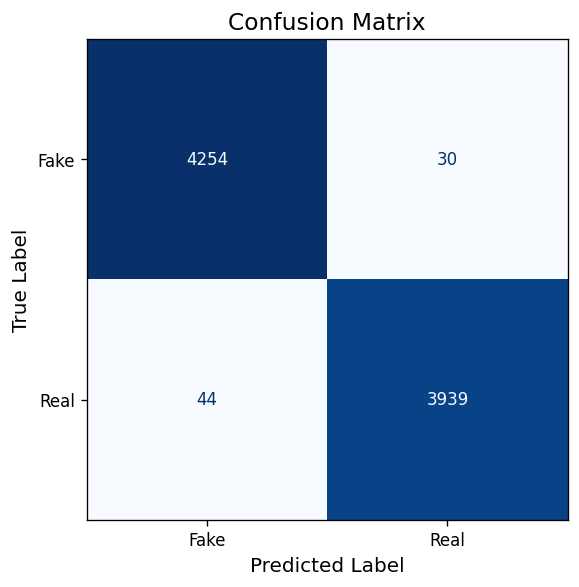

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    values_format='d'
)

ax.set_title("Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(False)
plt.tight_layout()

In [12]:
# Prepara X e y da ogni set
X_train = np.array(df_train['embedding'].tolist())
y_train = df_train['label'].values

X_val = np.array(df_validation['embedding'].tolist())
y_val = df_validation['label'].values

X_test = np.array(df_test['embedding'].tolist())
y_test = df_test['label'].values

# Crea il modello di regressione logistica
lr = LogisticRegression(
    max_iter=1000,
    solver='saga',
    random_state=42
)

# Allena il modello
lr.fit(X_train, y_train)

# Valutazione sul validation set
print("Validation Set:")
y_val_pred = lr.predict(X_val)
print(classification_report(y_val, y_val_pred, target_names=['Fake', 'Real']))

# Valutazione sul test set
print("Test Set:")
y_test_pred = lr.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=['Fake', 'Real']))


Validation Set:
              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97      3089
        Real       0.96      0.97      0.97      2911

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000

Test Set:
              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97      4284
        Real       0.97      0.97      0.97      3983

    accuracy                           0.97      8267
   macro avg       0.97      0.97      0.97      8267
weighted avg       0.97      0.97      0.97      8267



In [ ]:
joblib.dump(mlp, 'classifier.pkl')